In [1]:
!pip install langdetect spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=05278abcff35060f15c48d4c6effb9942a0fb9f9cf7bf7afb5a9b82c29daec5d
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import wordcloud
import seaborn as sns
import langdetect
from langdetect import detect, DetectorFactory
import spacy # Handle english text
import nltk

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Importing dataset and take a look at the first 5 rows
reddit_employ = pd.read_csv("/content/drive/MyDrive/ML/data/raw/reddit_employment_master.csv")
reddit_employ.head()

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with ...,https://preview.redd.it/1ry0labugyig1.png?widt...,Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2e...
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -...,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e...
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is th...","Hello,\n\nfor planning a first trip to North V...",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2d...
3,VietNam,bug bite help,"Hi, I’ve had this bug bite for over a week and...",lilpress13,6,32,2026-02-11 18:11:06,https://i.redd.it/k0jayy3l6yig1.jpeg
4,VietNam,My friend just lost her mom,"Hi, \n\nMy good friend and coworker lost her m...",MeowMeow_77,6,4,2026-02-11 16:00:16,https://www.reddit.com/r/VietNam/comments/1r29...


In [5]:
# Review number of entries and columns
reddit_employ.shape

(2800, 8)

In [6]:
reddit_employ.describe()

,score,num_comments
count,2800.000000,2800.000000
mean,106.477500,27.591786
std,550.877377,58.805972
min,0.000000,0.000000
25%,1.000000,3.000000
50%,8.000000,9.000000
75%,48.000000,26.000000
max,18642.000000,787.000000


In [7]:
# Created a copy of the reddit_employ dataset
pd.set_option("display.max_colwidth", None) # Take a peak at the whole text to see the usual pattern of a thread
reddit_df = reddit_employ.copy()
reddit_df.head(3)

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with clean broth,"https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC.",Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2ecng/how_to_cook_authentic_hanoi_style_pho_ga_with/
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one?","Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver.",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2dj6j/moc_chau_ta_xua_ha_giang_sapa_which_is_the_least/


Since we intentionally scrape 200 topics from each subreddits, we can expect a pretty balanced distribution among the subreddits

/tmp/ipython-input-4294811868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = subreddit_counts,


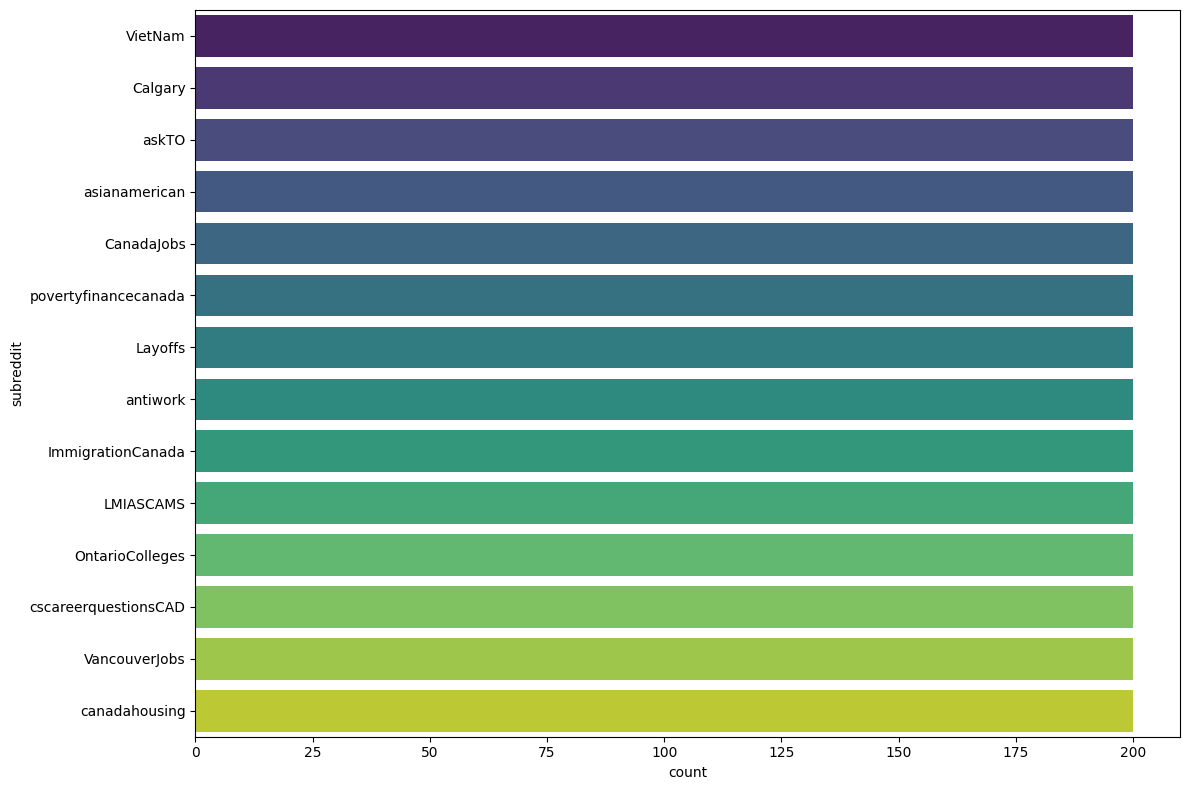

In [8]:
# Count how many texts are there in each subreddits
subreddit_counts = reddit_df['subreddit'].value_counts().reset_index()
subreddit_counts.columns = ['subreddit', 'count']

plt.figure(figsize =(12, 8))
sns.barplot(data = subreddit_counts,
            x = 'count', y = 'subreddit',
            palette = 'viridis')

plt.tight_layout()
plt.savefig('subreddit_counts.png')
plt.show()

In [9]:
# Checking for any null values
reddit_df.isnull().sum()

,0
subreddit,0
title,0
selftext,449
author,0
score,0
num_comments,0
created_utc,0
url,0


There're approximately 449 text that are null in the `selftext` column, let's fill null values with blank spaces first for NLP purpose later.

In [10]:
# Fill `selftext` column with "" first
reddit_df['selftext'] = reddit_df['selftext'].fillna("")
print(reddit_df.isnull().sum())

subreddit       0
title           0
selftext        0
author          0
score           0
num_comments    0
created_utc     0
url             0
dtype: int64


In [11]:
# Combine `title` & `selftext` columns together since titles contain the main ideas, selftext contains details => more convenients when doing EDA later
reddit_df['full_text'] = reddit_df['title'] + " " + reddit_df["selftext"]
# check the full_text column
reddit_df['full_text'].head()

,full_text
0,"How to cook authentic Hanoi style Pho Ga with clean broth https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC."
1,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?
2,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one? Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver."
3,"bug bite help Hi, I’ve had this bug bite for over a week and it keeps getting larger despite topical medicine from the pharmacy. The yellowish ring is one of the medicines they gave me. It is incredibly itchy. It hasn’t gotten better after over three days of the medicine, does anyone know what it could be/is it cause for concern/should I go to a doctor? It’s about the size of a quarter. I am in central Vietnam. I also have a sore throat but am not sure if they are related. I have no other symptoms. Thank you for any help 🙇‍♀️♥️"
4,"My friend just lost her mom Hi, \n\nMy good friend and coworker lost her mom earlier this week. My friend is originally from Vietnam and I would like to show respect and sympathy. My coworkers and I are pulling money together to get a gift for her. I was wondering if there is anything special or traditional that we can do for her. We are in the states and typically have a card that everyone signs and flowers. Is there anything else I can do for her? \n\nThank you in advance."


The subreddits are mostly in English, the rest are other languages (including Vietnamese). Since our concerns in this project is about Vietnamese and English, we'll sort out other languages (e.g. French, Japanese, etc.)

## 2. Language detection
Since `underthesea` is for Vietnamese, we'll need `Spacy` to work with English

- Devide the datasets into two: `english_df` and `vietnamese_df`, for those text that contains both english and vietnamese (Vinglish), prioritize the one that outnumber

In [12]:
from langdetect import detect

def get_language(text):
    try:
        return detect(text)
    except:
        return "uknown"

# Apply the function to create another columns
reddit_df['language'] = reddit_df['full_text'].apply(get_language)

# Create 2 different datasets with vietnames and english
reddit_vn = reddit_df[reddit_df['language'] == "vi"].copy()
reddit_en = reddit_df[reddit_df['language'] == "en"].copy()

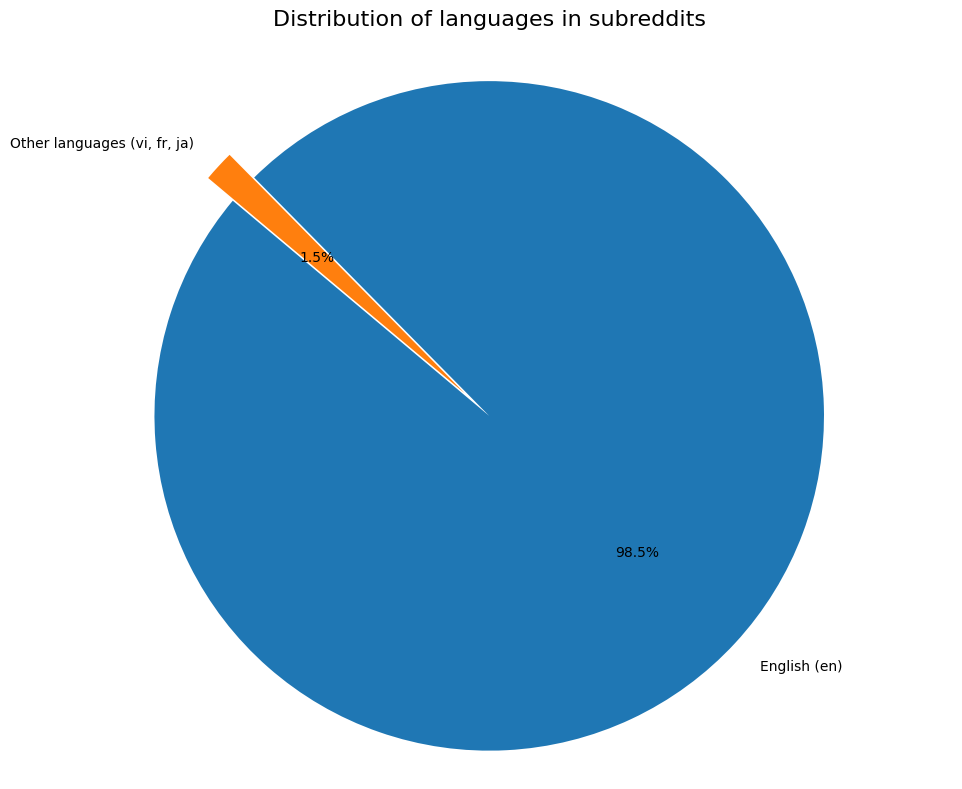


Detailed Distribution table:
language
en        2758
vi           7
de           7
fr           7
nl           5
ca           3
so           2
ro           2
tl           2
sw           2
uknown       1
sk           1
cy           1
it           1
da           1
Name: count, dtype: int64


In [13]:
# Make sure the results are reproducible
DetectorFactory.seed = 0

lang_counts = reddit_df['language'].value_counts()
en_counts = lang_counts.get('en', 0) # Separate subreddits with english apart from the others
other_counts = lang_counts.sum() - en_counts
# Create a new series to draw chart
lang_plot_data = pd.Series({
    "English (en)": en_counts,
    "Other languages (vi, fr, ja)": other_counts
})

#Draw a pie chart
plt.figure(figsize = (10, 8))
# colors = ['']
plt.pie(
    lang_plot_data,
    labels=lang_plot_data.index,
    autopct= "%1.1f%%", # show percentage
    startangle=140,
    explode=(0, 0.1),  # Create small spaces between slices for easy visibility
)
plt.title("Distribution of languages in subreddits", fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig("language_distribution_chart.png")
plt.show()

print("\nDetailed Distribution table:")
print(lang_counts)

In [14]:
print(f"Subreddits contains Vietnamese has {reddit_vn.shape[0]} rows and {reddit_vn.shape[1]} columns")
print(reddit_vn['full_text']) # Take a peek at these subreddits

Subreddits contains Vietnamese has 7 rows and 10 columns
8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               PUERTO RICO LÃNH THỔ MỸ - DI SẢN KHIẾN THẾ GIỚI NGÃ MŨ VÀ ĐẤU ĐÁ MG Puerto Rico không nổi lên nhờ may mắn. Nó được tôi luyện qua 500 năm va chạm giữa Tây Ban Nha, Mỹ và bản sắ

We can see that with these text, even when there are Vietnamese, some of them are still written mainly in English, we can see that even with immigrants, in this case Vietnamese immigrants, **we still prioritize using English to navigate through the procecss of settling down or receiving helps from international friends**.
=> Therfore, we still use `underthesea` to extract important features from these 7 subreddits but our main focus will be on the rest of the dataset, which is mostly written in English

In [ ]:
def process_vietnamese(text):
  # Tokenize Vietnamese words
  tokens = word_tokenize(text, format="text")
  #
  tags = pos_tag(text)
  return tokens

## 3. Data Cleaninga & Pre-processing

Use `Spacy` for lowercase, remove stopwords and Lemmatization all at one.
We don't want to set everything in lowercase first since there might be some "misunderstanding" happening (e.g. python and Python - programming language). Besides, remove punctuation first will affect Spacy ability to parse dependency. For numbers, spacy has IS_DIGIT which will help remove them

Extrapolating keywords (might take roughly 1-2 minutes for 2700 texts)...

Top 20 keywords:
        Keyword  Count
0           job   1834
1          year   1341
2          time   1082
3        people    827
4    experience    802
5          work    787
6       company    690
7           day    687
8        canada    675
9         month    652
10         role    606
11     position    518
12         lmia    508
13      program    471
14       worker    431
15        thing    425
16         week    412
17  application    390
18       advice    387
19       school    333


/tmp/ipython-input-976979261.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = reddit_top_20, x="Count", y="Keyword", palette="magma")


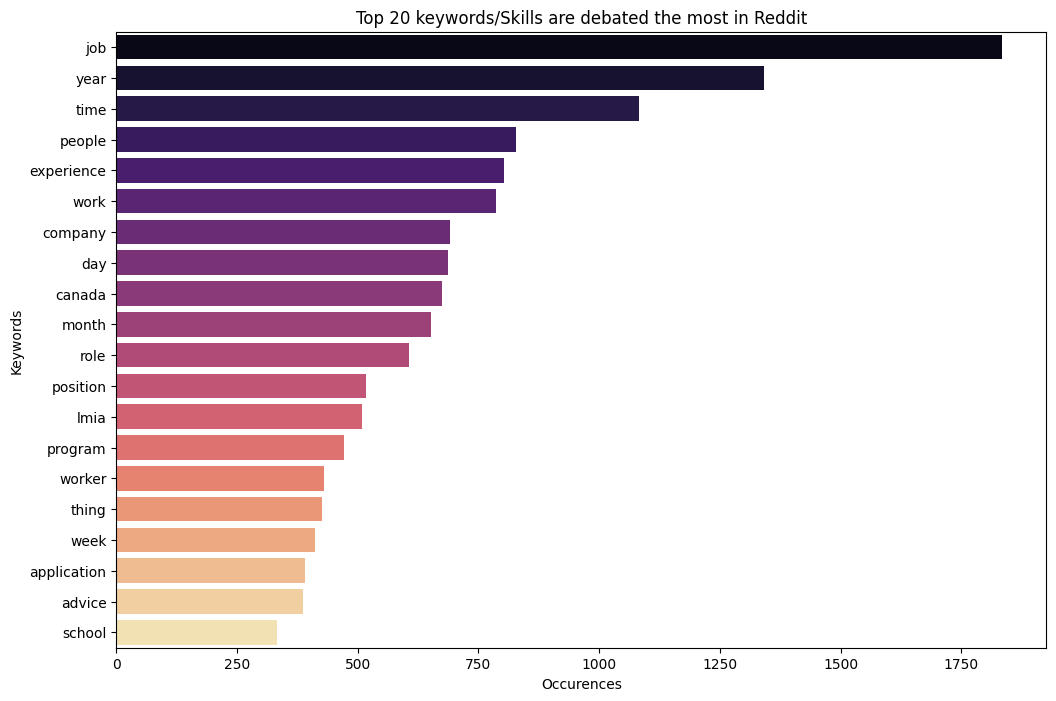

In [15]:
from collections import Counter
# 1. Load model
nlp = spacy.load("en_core_web_sm")
# Define function to process the text
def get_keywords(text):
    doc = nlp(text[:10000])

    # Get PROPN and NOUN
    keywords = [
        token.lemma_.lower() for token in doc
        if (token.pos_ in ['PROPN', 'NOUN'])
        and not token.is_stop
        and not token.is_punct
    ]
    return keywords

print ("Extrapolating keywords (might take roughly 1-2 minutes for 2700 texts)...")

# Apply it to the reddit_en
all_keywords = []
for text in reddit_en['full_text']:
    all_keywords.extend(get_keywords(text))

# Get top 20 keywords
top_keywords = Counter(all_keywords).most_common(20)

# Create dataframe to plot the chart
reddit_top_20 = pd.DataFrame(top_keywords, columns = ['Keyword', 'Count'])
print("\nTop 20 keywords:")
print(reddit_top_20)

plt.figure(figsize = (12, 8))
sns.barplot(data = reddit_top_20, x="Count", y="Keyword", palette="magma")
plt.title("Top 20 keywords/Skills are debated the most in Reddit")
plt.xlabel("Occurences")
plt.ylabel("Keywords")
plt.savefig('top_20_keywords.png')
plt.show()

From the chart, we can see a few things:
- Top 20 keywords are mostly about **work** (e.g. work, job, experience, position, role, worker, lmia (Labour Market Impact Assessment - very import for immigrants), others words that don't tell much about the topic (e.g. month, day, canada, thing)
- We can see that the immigrants are really concerned about whether they will get LMIA in order to be able to stay in Canada legally for living and working purpose
- If the frequency of LMIA occur with negative words (e.g. scam, fake, pay) increases, it's something that we need to take into account of.

- We can use `Phrase Matching`  to group the similar definitions of immigration/work in Canada:


In [44]:
# # Adding extra terminologies into the list
# special_terms = ["lmia", "pr", "pgwp", "it", "hr"]

# def get_refined_keywords(text):
#   doc = nlp(text[:10000])
#   keywords = []
#   for token in doc:
#     lemma = token.lemma_.lower()
#     if (token.pos_ in ["PROPN", "NOUN"] or lemma in special_terms) \
#       and not token.is_stop \
#       and not token.is_alpha and len(lemma) > 1:
#         keywords.append(lemma)
#     return keywords

# all_words = [word for text in reddit_en['full_text'] for word in get_refined_keywords(text)]

In [22]:
# Get top 10 keywordsthat are related to "lmia"
# top_10_word = Counter(all_words).most_common(10)
# top_10_word

[('cb3', 2),
 ('1d', 1),
 ('1st', 1),
 ('latimes.404', 1),
 ('wantedme.com', 1),
 ('h&amp;r', 1),
 ('u.s.', 1),
 ('30k', 1),
 ('p2', 1),
 ('c10', 1)]

If we follow the steps above, we will have a list that is, honestly, incomprehensible, we'll use bigrams to take care of this problem (try to match the words in pair - LMIA support, LMIA scam - in order for the sentence to make more sense)

In [16]:
# Clean some more "Reddit trash"
cleaned_words = [
    word for word in all_keywords if word.isalpha() # Remove !, ?, 123, &
    and len(word) > 2 # Keep words whose len > 2 (remove "i", "am")
    and word not in ['amp', 'http', 'https', 'reddit', 'post',
                     'get', 'know', 'think', 'want'] # Common Reddit trashs
]

In [17]:
len(cleaned_words)

93464

In [18]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
# Instantiate the Bigrams measures
bigram_measures = BigramAssocMeasures()

# Create a finder
finder = BigramCollocationFinder.from_words(cleaned_words)

# Only keep the words appearing > 3 times to remove trash
finder.apply_freq_filter(3)

# Filter: only keeps the words that have "lmia"
lmia_filter = lambda w1, w2: "lmia" not in (w1.lower(), w2.lower())
finder.apply_ngram_filter(lmia_filter)

# 3. Tot 10 most popular "lmia terms"
top_lmia_phrases = finder.nbest(bigram_measures.pmi, 10)
print("Top 10 most meaningful terms related to LMIA")
for phrase in top_lmia_phrases:
  print(f"{phrase[0]} {phrase[1]}")


Top 10 most meaningful terms related to LMIA
lmia map
map lmia
lmia scam
resource lmia
lmia justification
resources lmia
cook lmia
mechanic lmia
lmia approval
lmia guideline


/tmp/ipython-input-2992663747.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = lmia_data,


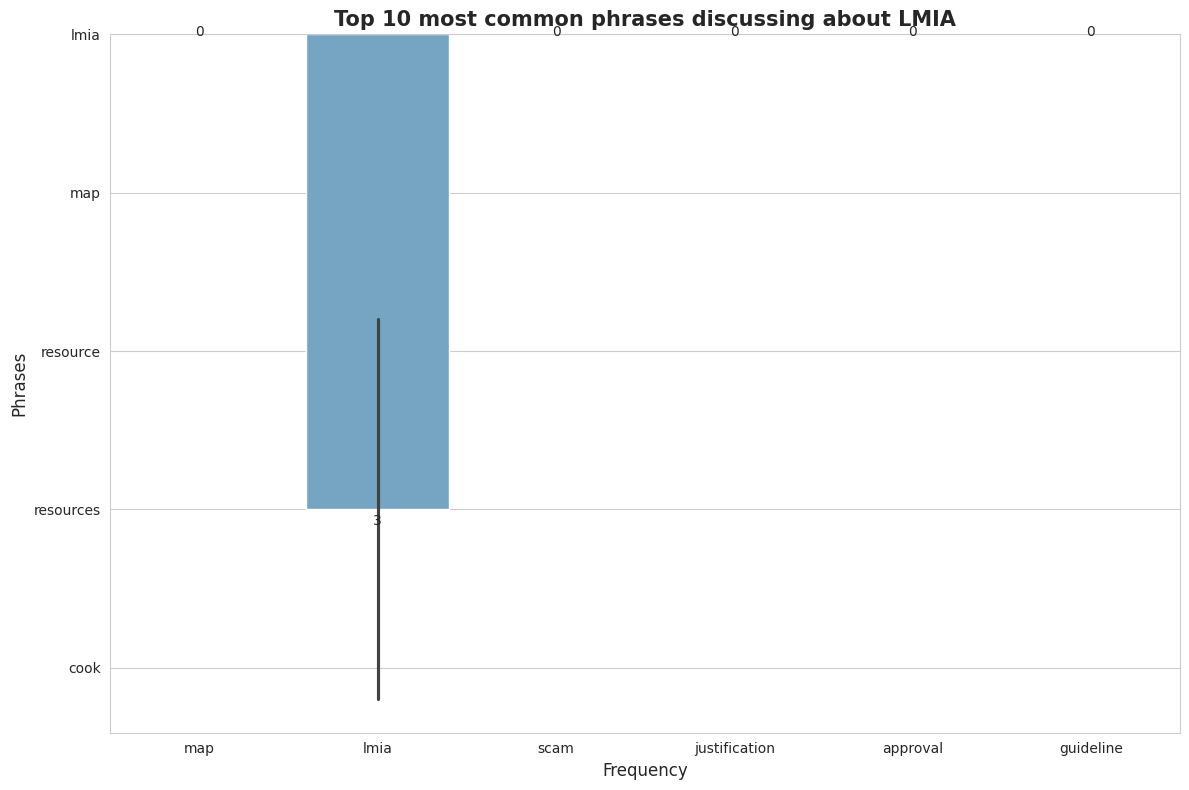

In [59]:
# Plot a horizontal bar chart about top 10 LMIA keywords
plt.figure(figsize = (12, 8))
lmia_data = pd.DataFrame(top_lmia_phrases, columns = ['Phrases', 'Frequency'])
sns.set_style("whitegrid")
ax = sns.barplot(data = lmia_data,
            x = 'Frequency', y = 'Phrases',
            palette = 'Blues_d')

# Adding numbers for better visibility
for i in ax.containers:
  ax.bar_label(i,padding=3)

plt.title("Top 10 most common phrases discussing about LMIA", fontsize=15, fontweight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Phrases", fontsize=12)
plt.tight_layout()
plt.show()

**Stacked Bar Chart (Top skills mentioned by Industry)**: nếu phân loại được ngành nghề (IT, Marketing, ...) biểu đồ này sẽ chỉ ra SKILLS nào đang chiếm sóng trong mỗi

Plot for hard skills likes: Python, SQL, Java, etc.
Plot for keywords related to "LMIA, PR, Permit"

Since the null column in `selftext` takes roughly 16% of the total dataset and Reddit users are more likely to express their ideas in the `title`

### Charts to include
1. Content and topic analysis:

**Bar chart** (Top N keywords/biagrams): đếm tần suất các cụm 2 từ như "tìm việc", "kinh nghiệm" "lương bổng" xuất hiện

**Topic modelling visualization (LDAvis)**: nhóm các bài viết thành chủ đề tự động => Cho thấy các bong bóng chủ đều tách biệt nhau như thế nào

2. Sentimental Analysis

**Pie chart/Donue chart** (Sentimental Distribution): So sánh xem cộng đồng ở Subreddits nào "bi quan" hay "lạc quan" hơn về thị trường lao động.

**Heatmap** (Sentiment vs. Time of Day/Day of Week): xem thử liệu các bài đăng vào thứ 2 (khi scrape) thường mang tâm trạng gì so với các ngày khác.

3. Trend and Engagement Analysis

**Time Series Line chart (post Volume/Time)**: Theo dõi số lượng bài đăng theo tuần/tháng. Nếu có 1 đợt sóng bài đăng đột ngột, có thể do 1 chính sách mới vừa ra đời.

**Scatter Plot** (Upvotes vs Number of Comments): xác định những chủ đề gây tranh cãi (debatable) hoặc được "quan tâm" nhất. Những bài ít vote nhưng nhiều cmmt thường là chủ đề gây tranh cãi.

**Stacked Bar Chart (Top skills mentioned by Industry)**: nếu phân loại được ngành nghề (IT, Marketing, ...) biểu đồ này sẽ chỉ ra SKILLS nào đang chiếm sóng trong mỗi

## 4. Text Mining EDA
1. Finding Top N-Grams
- English: might be "work permit", "PR", "PR process", "job market"
- Vietnamses: "xin việc", "định cư", "bằng cấp"
2. Word Cloud: draw 2 separate clouds for 2 languages to find the difference in concerns

## 5. Enagagement Analysis
- **Correlation**: Are the text about "immigrations" receive more upvotes than the ones with "food"/"recreation"?
- **Time**: Every time we scrape the dataset on Monday, check lượng thảo luận có tăng đột biến sau holidays hay chính sách mới không?

## 6. Initial Sentiment EDA
- Use simple libraries like `TextBlob` (for English) to see general attitude (negative or positive) before diving deeper into more complex models
- we can see **Polarity** (-1 -> 1) and **Subjectivity** (0 -> 1) - the higher the number, the more objective it's, the lower, the more truth it bears

In [21]:
from typing import Text
from textblob import TextBlob
def get_sentiment_score(text):
  return TextBlob(text).sentiment.polarity

# create a collumn named "sentiment_score" for reddit_en
reddit_en['sentiment_score'] = reddit_en['full_text'].apply(get_sentiment_score)

# Function to compare emotions between keywords
def analyze_keyword_sentiment(keyword, dataframe):
  # Filter text with keywords, either upper or lowercase
  relevant_posts = dataframe[dataframe['full_text'].str.contains(keyword, case=False)]
  avg_score = relevant_posts['sentiment_score'].mean()
  count = len(relevant_posts)
  return avg_score, count

# Test with LMIA and programming languages
keywords_test = ['lmia', 'python', 'java', 'sql', 'javascript']
results = []
for k in keywords_test:
  score, count = analyze_keyword_sentiment(k, reddit_en)
  results.append({"Keyword": k, "Avg Sentiment": score, "Post count": count})

df_sentiment = pd.DataFrame(results)
print(df_sentiment)

      Keyword  Avg Sentiment  Post count
0        lmia       0.074255         136
1      python       0.129373          14
2        java       0.091501          22
3         sql       0.134334          11
4  javascript       0.154802           4


/tmp/ipython-input-1023807677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sentiment, x='Keyword', y='Avg Sentiment', palette='RdYlGn')


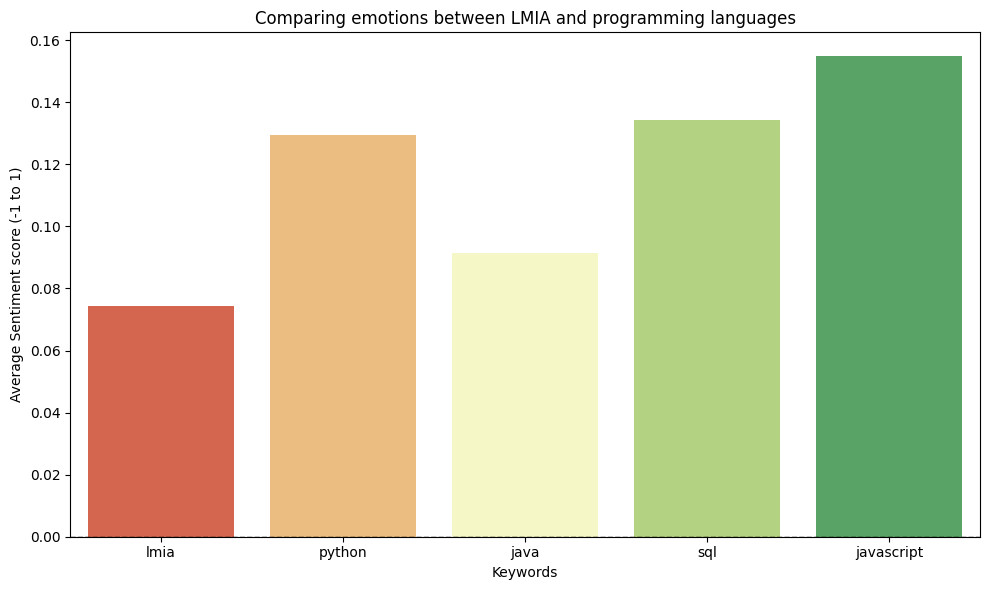

In [23]:
# Let see how emotions are tie to these keywords
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sentiment, x='Keyword', y='Avg Sentiment', palette='RdYlGn')
plt.axhline(0, color="black", linestyle="--", linewidth = 1)
plt.title("Comparing emotions between LMIA and programming languages")
plt.ylabel("Average Sentiment score (-1 to 1)")
plt.xlabel("Keywords")
plt.tight_layout()
plt.savefig("sentiment_analysis.png")
plt.show()

From this chart, we can see that there's a clear polarity in the immigrants' minds.
* When it comes to LMIA, this topic is the most stressful and concerning with the immigrants since it's heavily tied to the chance of being able to settle down and working in Canada.
- Users usually ask questions such as (How to..., I need help with..., Can someone explain...) and they usually include words like "please, thanks" that inadvertently increase the score a bit.
* While the programming skills bears more positivity, usually these skills are included in the subreddits related to **Web Development, React, FreeLance** these are the constructive topics, with less or nothing having to do with emotions.
* Regarding *Java*, this keyword usually appear in subreddits about Enterprise, which might explain why the emotional score is a bit lower (stable job with less excitement).

=> Insight for the recruiters: Immigrants workers are especially sensitive and a bit guarding against anything that is related to LMIA, company and enterprise should be more clear when it comes to this matter to build trust.

In [36]:
#Get posts that are related to Python keywors
python_posts = reddit_en[reddit_en['full_text'].str.contains(r'\bpython\b', case=False, na=False, regex=True)].copy()
python_posts.shape

(14, 11)

In [37]:
pet_keywords = ['snake', 'ball', 'pet', 'animal',
                'morph', 'tank', 'rehome', 'breed', 'reptile']
def check_python_context(text):
  if any(word in text for word in pet_keywords):
    return "Pet/Animal"
  return "Coding/Tech"

# Take a peek at the categories after processing
python_posts['category'] = python_posts['full_text'].apply(check_python_context)


,category
206,Pet/Animal
804,Coding/Tech
846,Pet/Animal
2221,Pet/Animal
2243,Coding/Tech
2249,Pet/Animal
2291,Coding/Tech
2298,Coding/Tech
2328,Coding/Tech
2353,Pet/Animal


In [ ]:
python_posts[python_posts['category'] == "Pet/Animal"][['subreddit', 'title', 'full_text', 'category']]

We can see that even with processing and trying to separate the Python programming skill apart from python the real animal, there're still some mismatch in categorizing, however this also implies that **most of the subreddits we scraped are truly from people concerning about their jobs and the job markets, which fortifies our finding above, that Python, SQL and javascript are still one of the programming languages that most people are learning.**

In [ ]:
# analyze "java" posts
java_posts = reddit_en[reddit_en['full_text'].str.contains(r"\bjava\b", case=False, regex=True, na=False)].copy()
java_posts[['subreddit', 'full_text', 'sentiment_score']]

As expected, when it comes to java, most people are talking about resume review and job that are more stable.

In [50]:
# Get some examples about LMIA
scam_keywords = ['scam', 'fake', 'loophole', 'fraud', 'illegal', 'pay']
lm_scam_pattern = "|".join(scam_keywords)
lm_scam_posts = reddit_en[reddit_en['full_text'].str.contains('lmia', case=False) &
                  reddit_en['full_text'].str.contains(lm_scam_pattern, case=False)
]

print(f"Found {len(lm_scam_posts)} subreddits that might related to LMIA Scams")

Found 113 subreddits that might related to LMIA Scams


In [51]:
print("\n-- Some examples about LMIA scams for recruiters--")
for i, row in lm_scam_posts.head(3).iterrows():
  print(f"Subreddit: {row['subreddit']}")
  print(f"Title: {row['title']}")
  print(f"{TextBlob(row['full_text']).sentiment.polarity:.2f}")


-- Some examples about LMIA scams for recruiters--
Subreddit: CanadaJobs
Title: Is entry -level job market in Canada officially dead?
0.06
Subreddit: CanadaJobs
Title: Issues/topics you want to know more about or bring attention to as a Canadian job seeker?
0.23
Subreddit: LMIASCAMS
Title: CB3 INC in Brossard, QC is claiming they couldn't find a fast food restaurant manager for $57607.68/year. They've applied for a LMIA to hire a temporary foreign worker for the position.
0.13
